In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [2]:
adult = pd.read_csv("./cov_results/adult_rapproach.csv")
math = pd.read_csv("./cov_results/math_rapproach.csv")
port = pd.read_csv("./cov_results/portuguese_rapproach.csv")
product = pd.read_csv("./cov_results/productivity_rapproach.csv")


In [3]:
adult

,Budget,Agents_Covered,Total_Agents,Target_1_Radius
0,4.0,183,328,3.999072
1,4.5,223,328,4.469744
2,5.0,271,328,4.977221
3,5.5,301,328,5.492633
4,6.0,311,328,5.995811
5,6.5,317,328,6.338996
6,7.0,325,328,6.766378
7,7.5,327,328,7.455014
8,8.0,328,328,7.607544
9,8.5,328,328,7.607544


In [4]:
math

,Budget,Agents_Covered,Total_Agents,Target_15_Radius
0,4.0,4,206,3.958801
1,4.5,7,206,4.196967
2,5.0,17,206,4.990810
3,5.5,38,206,5.486520
4,6.0,58,206,5.998817
5,6.5,92,206,6.489508
6,7.0,121,206,6.990663
7,7.5,146,206,7.459367
8,8.0,171,206,7.938078
9,8.5,189,206,8.465527


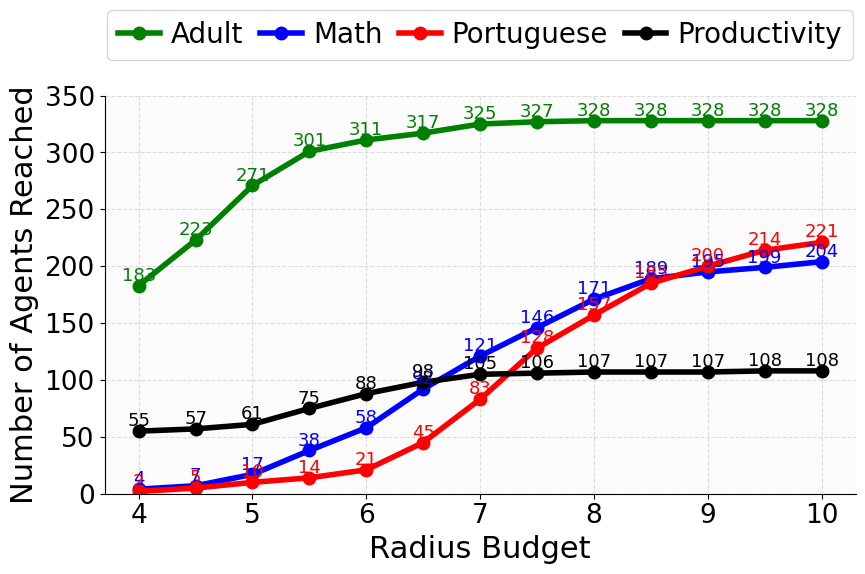

In [5]:
budgetsA, coveredA = adult["Budget"].to_numpy(), adult["Agents_Covered"].to_numpy()
budgetsM, coveredM = math["Budget"].to_numpy(), math["Agents_Covered"].to_numpy()
budgetsPo, coveredPo = port["Budget"].to_numpy(), port["Agents_Covered"].to_numpy()
budgetsPr, coveredPr = product["Budget"].to_numpy(), product["Agents_Covered"].to_numpy()


fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(budgetsA, coveredA, marker="o", markersize=9, linewidth=4, color="green", label="Adult")
ax.plot(budgetsM, coveredM, marker="o", markersize=9, linewidth=4, color="blue", label="Math")
ax.plot(budgetsPo, coveredPo, marker="o", markersize=9, linewidth=4, color="red", label="Portuguese")
ax.plot(budgetsPr, coveredPr, marker="o", markersize=9, linewidth=4, color="black", label="Productivity")

ax.set_xlabel("Radius Budget", fontsize=22)
ax.set_ylabel("Number of Agents Reached", fontsize=22)

ax.grid(True, linestyle="--", alpha=0.4)
ax.set_facecolor("#fbfbfb")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ymin = min(coveredA.min(), coveredM.min(), coveredPo.min(), coveredPr.min())
ymax = max(coveredA.max(), coveredM.max(), coveredPo.max(), coveredPr.max())
yrange = max(1, ymax - ymin)
pad = max(5, yrange * 0.03) 

lower = max(0, ymin - pad) 
upper = ymax + pad
ax.set_ylim(lower, upper)

all_budgets = sorted(set(budgetsA) | set(budgetsM) | set(budgetsPo) | set(budgetsPr))
ax.set_xticks(all_budgets)
ax.set_yticks(ax.get_yticks())
ax.tick_params(axis="x", labelsize=19)
plt.yticks(fontsize=19)

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=7))


for x, y in zip(budgetsA, coveredA):
    ax.text(x, y + pad * 0.08, f"{int(y)}", ha="center", va="bottom", fontsize=13, color="green")
for x, y in zip(budgetsM, coveredM):
    ax.text(x, y + pad * 0.08, f"{int(y)}", ha="center", va="bottom", fontsize=13, color="blue")
for x, y in zip(budgetsPo, coveredPo):
    ax.text(x, y + pad * 0.08, f"{int(y)}", ha="center", va="bottom", fontsize=13, color="red")
for x, y in zip(budgetsPr, coveredPr):
    ax.text(x, y + pad * 0.08, f"{int(y)}", ha="center", va="bottom", fontsize=13, color="black")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),  
    ncol=4,                     
    frameon=True, 
    handlelength=1.5, handletextpad=0.4, columnspacing=0.6, labelspacing=0.15,
    fontsize=20
)


plt.tight_layout()
plt.savefig("./cov_results/figures/alldatasets_radius.pdf", dpi=300, bbox_inches='tight')

plt.show()
